# Part 1: Sentiment Analysis via the ML-based approach

Download the “Product Sentiment” dataset from the course portal: sentiment_train.csv and sentiment_test.csv.

### Part 1.a. Loading and Prep

Load, clean, and preprocess the data as you find necessary.

In [ ]:
import pandas as pd
# TODO: import other libraries as necessary
import nltk
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from nltk import pos_tag
from nltk import ngrams
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, cross_val_score

import warnings
warnings.filterwarnings('ignore')


In [ ]:
#Load the train data
df_train = pd.read_csv("/content/sentiment_train.csv")

print(df_train.info())
print(df_train.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Sentence  2400 non-null   object
 1   Polarity  2400 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 37.6+ KB
None
                                            Sentence  Polarity
0                           Wow... Loved this place.         1
1                                 Crust is not good.         0
2          Not tasty and the texture was just nasty.         0
3  Stopped by during the late May bank holiday of...         1
4  The selection on the menu was great and so wer...         1


In [ ]:
#Load the test data
df_test = pd.read_csv("/content/sentiment_test.csv")

print(df_test.info())
print(df_test.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Sentence  600 non-null    object
 1   Polarity  600 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 9.5+ KB
None
                                            Sentence  Polarity
0  A good commentary of today's love and undoubte...         1
1  For people who are first timers in film making...         1
2  It was very popular when I was in the cinema, ...         1
3  It's a feel-good film and that's how I felt wh...         1
4  It has northern humour and positive about the ...         1


<Axes: xlabel='Polarity'>

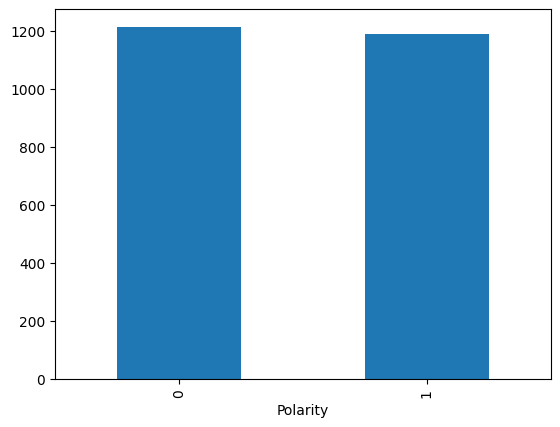

In [ ]:
#Data exploration
df_train['Polarity'].value_counts().plot.bar()

In [ ]:
import nltk
nltk.download('punkt')         # for tokenization
nltk.download('stopwords')     # for removing stopwords
nltk.download('wordnet')       # for lemmatization
nltk.download('averaged_perceptron_tagger')  # for POS tagging

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


True

In [ ]:
# Text Preprocessing
def firstpreprocess_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)

    # Tokenize the text
    tokens = word_tokenize(text)

    # Apply n-grams (e.g., bigrams)
    n = 2  # For bigrams
    n_grams_list = list(ngrams(tokens, n))

    # Select the first 20 n-grams
    selected_n_grams = n_grams_list[:20]

    # Flatten the list of n-grams
    flat_tokens = [token for gram in selected_n_grams for token in gram]

    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    filtered_tokens = [word for word in flat_tokens if word not in stop_words]

    # Lemmatize the tokens
    lemmatizer = WordNetLemmatizer()
    lemmatized_tokens = [lemmatizer.lemmatize(word) for word in filtered_tokens]

    # Join the tokens back into a string
    return ' '.join(lemmatized_tokens)


In [ ]:
#Apply Text Preprocessing function to train and text data
df_train['cleaned_sentence'] = df_train['Sentence'].apply(firstpreprocess_text)
df_test['cleaned_sentence'] = df_test['Sentence'].apply(firstpreprocess_text)

In [ ]:
df_train['cleaned_sentence'].head()

,cleaned_sentence
0,wow loved loved place
1,crust good
2,tasty tasty texture texture nasty
3,stopped late late may may bank bank holiday ho...
4,selection selection menu menu great great price


**Certain words such as 'is', 'not' in the second column were no longer in the Sentence after text preprocessing due to removal of stop words. Will be on the lookout how this will affect model performance.**

In [ ]:
df_test['cleaned_sentence'].head()

,cleaned_sentence
0,good good commentary commentary today today lo...
1,people people first first timer timer film fil...
2,popular popular cinema cinema good good house ...
3,feelgood feelgood film film thats thats felt f...
4,northern northern humour humour positive posit...


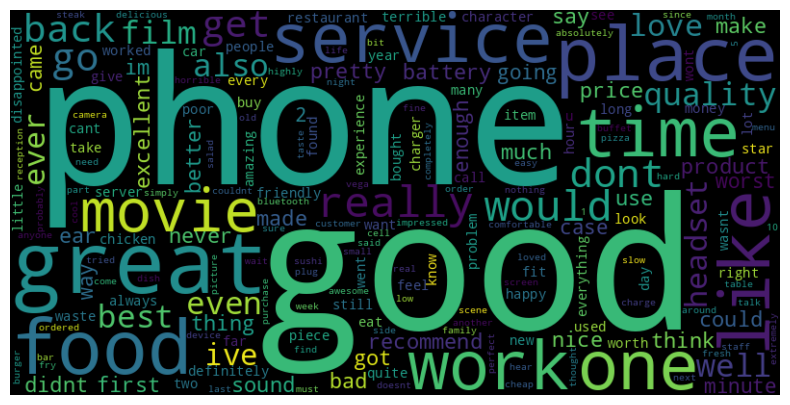

In [ ]:
#Visualize the most common words
from collections import Counter

# Combine all cleaned sentences into a single string
all_text = ' '.join(df_train['cleaned_sentence'].astype(str).tolist())

# Tokenize the text and count word frequencies
words = all_text.lower().split()
word_freq = Counter(words)


from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(width=800, height=400).generate_from_frequencies(word_freq)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

**Seems like reviews for movies/services at a cinema.**

In [ ]:
# TF-IDF Vectorization (Convert sentences into numerical form)
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(df_train['cleaned_sentence'])
X_test_tfidf = tfidf.transform(df_test['cleaned_sentence'])

# Target variable
y_train = df_train['Polarity']
y_test = df_test['Polarity']

In [ ]:
from imblearn.over_sampling import SMOTE

# Handle imbalanced data using SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_tfidf, y_train)

### Part 1.b. Modeling

Use your favorite ML algorithm to train a classification model.  Don’t forget everything that we’ve learned in our ML course: hyperparameter tuning, cross validation, handling imbalanced data, etc. Make reasonable decisions and try to create the best-performing classifier that you can.

In [ ]:
# TODO

In [ ]:
# Logistic Regression with class weighting to handle imbalance
model = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')

# Cross-validation to evaluate performance
cross_val_scores = cross_val_score(model, X_train_resampled, y_train_resampled, cv=5, scoring='f1')
print(f"Cross-validated F1 scores: {cross_val_scores}")
print(f"Average F1 score: {cross_val_scores.mean()}")

# Hyperparameter tuning using GridSearchCV
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],  # Regularization
    'solver': ['lbfgs', 'saga', 'liblinear']  # Solvers for logistic regression
}

grid_search = GridSearchCV(model, param_grid, cv=5, scoring='f1')
grid_search.fit(X_train_resampled, y_train_resampled)

print(f"Best Hyperparameters: {grid_search.best_params_}")

# Train the final model using the best hyperparameters
best_model = grid_search.best_estimator_
best_model.fit(X_train_resampled, y_train_resampled)

Cross-validated F1 scores: [0.71493213 0.7875     0.792      0.7405765  0.60053619]
Average F1 score: 0.7271089632800761
Best Hyperparameters: {'C': 10, 'penalty': 'l2', 'solver': 'saga'}


LogisticRegression(C=10, class_weight='balanced', max_iter=1000,
                   random_state=42, solver='saga')

### Part 1.c. Assessing

Use the testing data to measure the accuracy and F1-score of your model.  

In [ ]:
# TODO


In [ ]:
# Evaluate the model on the test data
y_pred = best_model.predict(X_test_tfidf)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"F1-Score: {f1:.4f}")

# Detailed classification report
#print(classification_report(y_test, y_pred))

# Confusion matrix
import pandas as pd
from sklearn import metrics # import the metrics module

df = pd.DataFrame(metrics.confusion_matrix(y_test,y_pred), index=['0','1'], columns=['0','1'])
df

Accuracy: 0.7783
F1-Score: 0.7679


,0,1
0,247,40
1,93,220


### Part 2. Given the accuracy and F1-score of your model, are you satisfied with the results, from a business point of view? Explain.

TODO: Insert your answer here.

**No, I am not fully satisfied. While the model's accuracy score of 0.7783 and F1-score of 0.7679 are reasonably good, they may still lead to business implications due to misclassifications. For instance, in a business-critical environment such as safety product development like cars, misclassifying 22.17% of reviews could lead to serious business implications.**

**From a business perspective, a higher F1-score and accuracy are desirable, especially if the impact of incorrect sentiment prediction is significant. Although the data seemed to be reviews for films/cinema, wherein a 0.7783 accuracy score maybe an acceptable baseline, the model performance can further be improved.**

### Part 3. Show five example instances in which your model’s predictions were incorrect. Describe why you think the model was wrong. Don’t just guess: dig deep to figure out the root cause.

TODO: Insert your answer here.

**From the five instances below (code output below) and as earlier observed after text preprocessing, the removal of stop words removed context for instance the apstrophe in 'wasn't' and also words such as 'not' and 'too' which can be great in distinguishing positive and negative sentiments.**

**Try to improve the model by using different techniques in text preprocessing.**

In [ ]:
# TODO: Feel free to use code as well to answer this question. Or not. Up to you.

In [ ]:
import numpy as np
# Find incorrect predictions
incorrect_indices = np.where(y_pred != y_test)[0]
incorrect_samples = df_test.iloc[incorrect_indices]

# Show five incorrect predictions and analyze why they are wrong
print("Examples of incorrect predictions:")
for i in range(min(5, len(incorrect_samples))):
    print(f"Sentence: {incorrect_samples.iloc[i]['Sentence']}")
    print(f"Cleaned Sentence: {incorrect_samples.iloc[i]['cleaned_sentence']}")
    print(f"Predicted Polarity: {y_pred[incorrect_indices[i]]}, Actual Polarity: {incorrect_samples.iloc[i]['Polarity']}")
    print('-' * 100)


Examples of incorrect predictions:
Sentence: It's a feel-good film and that's how I felt when I came out of the cinema!  
Cleaned Sentence: feelgood feelgood film film thats thats felt felt came came cinema
Predicted Polarity: 0, Actual Polarity: 1
----------------------------------------------------------------------------------------------------
Sentence: It really created a unique feeling though.  
Cleaned Sentence: really really created created unique unique feeling feeling though
Predicted Polarity: 0, Actual Polarity: 1
----------------------------------------------------------------------------------------------------
Sentence: A world better than 95% of the garbage in the theatres today.  
Cleaned Sentence: world world better better 95 95 garbage garbage theatre theatre today
Predicted Polarity: 0, Actual Polarity: 1
----------------------------------------------------------------------------------------------------
Sentence: I would have casted her in that role after ready the

# **Improve model performance by retaining stop words**

In [ ]:
#Reload the train data
df_train1 = pd.read_csv("/content/sentiment_train.csv")


In [ ]:
#Reload the test data
df_test1 = pd.read_csv("/content/sentiment_test.csv")

**Text Preprocessing**

In [ ]:
# Initialize lemmatizer
lemmatizer = WordNetLemmatizer()

def secondpreprocess_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)

    # Tokenize the text
    tokens = word_tokenize(text)

    # Apply n-grams (e.g., bigrams)
    n = 2  # For bigrams
    n_grams_list = list(ngrams(tokens, n))

    # Select the first 20 n-grams
    selected_n_grams = n_grams_list[:20]

    # Flatten the list of n-grams
    flat_tokens = [token for gram in selected_n_grams for token in gram]

    # Lemmatize the tokens
    lemmatized_tokens = [lemmatizer.lemmatize(word) for word in flat_tokens]

    # Join the tokens back into a string
    return ' '.join(lemmatized_tokens)


In [ ]:
# Apply the preprocessing function to the 'Sentence' column
df_train1['cleaned_sentence'] = df_train1['Sentence'].apply(secondpreprocess_text)
df_test1['cleaned_sentence'] = df_test1['Sentence'].apply(secondpreprocess_text)

In [ ]:
df_train1['cleaned_sentence'].head()

,cleaned_sentence
0,wow loved loved this this place
1,crust is is not not good
2,not tasty tasty and and the the texture textur...
3,stopped by by during during the the late late ...
4,the selection selection on on the the menu men...


In [ ]:
df_test1['cleaned_sentence'].head()

,cleaned_sentence
0,a good good commentary commentary of of today ...
1,for people people who who are are first first ...
2,it wa wa very very popular popular when when i...
3,it a a feelgood feelgood film film and and tha...
4,it ha ha northern northern humour humour and a...


In [ ]:
# TF-IDF Vectorization (Convert sentences into numerical form)
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf1 = tfidf.fit_transform(df_train1['cleaned_sentence'])
X_test_tfidf1 = tfidf.transform(df_test1['cleaned_sentence'])

# Target variable
y_train1 = df_train1['Polarity']
y_test1 = df_test1['Polarity']

In [ ]:
# Handle imbalanced data using SMOTE
smote = SMOTE(random_state=42)
X_train_resampled1, y_train_resampled1 = smote.fit_resample(X_train_tfidf1, y_train1)

**Modeling**

In [ ]:
# Logistic Regression with class weighting to handle imbalance
model1 = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')

# Cross-validation to evaluate performance
cross_val_scores = cross_val_score(model1, X_train_resampled1, y_train_resampled1, cv=5, scoring='f1')
print(f"Cross-validated F1 scores: {cross_val_scores}")
print(f"Average F1 score: {cross_val_scores.mean()}")

# Hyperparameter tuning using GridSearchCV
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],  # Regularization
    'solver': ['lbfgs', 'saga', 'liblinear']  # Solvers for logistic regression
}

grid_search = GridSearchCV(model1, param_grid, cv=5, scoring='f1')
grid_search.fit(X_train_resampled1, y_train_resampled1)

print(f"Best Hyperparameters: {grid_search.best_params_}")

# Train the final model using the best hyperparameters
best_model1 = grid_search.best_estimator_
best_model1.fit(X_train_resampled1, y_train_resampled1)


Cross-validated F1 scores: [0.77321814 0.80334728 0.81889764 0.78800857 0.62871287]
Average F1 score: 0.7624368994552443
Best Hyperparameters: {'C': 10, 'penalty': 'l2', 'solver': 'saga'}


LogisticRegression(C=10, class_weight='balanced', max_iter=1000,
                   random_state=42, solver='saga')

**Assessing the Model**

In [ ]:
# Evaluate the model on the test data
y_pred1 = best_model1.predict(X_test_tfidf1)

# Metrics
accuracy = accuracy_score(y_test1, y_pred1)
f1 = f1_score(y_test1, y_pred1)

print(f"Accuracy: {accuracy:.4f}")
print(f"F1-Score: {f1:.4f}")

# Detailed classification report
#print(classification_report(y_test, y_pred))

# Confusion matrix

df1 = pd.DataFrame(metrics.confusion_matrix(y_test1,y_pred1), index=['0','1'], columns=['0','1'])
df1


Accuracy: 0.7550
F1-Score: 0.7513


,0,1
0,231,56
1,91,222


***From the Accuracy score and F1-Score, retaining the stop words didn't improve the Logistic Regression model.***

**Incorrect Predictions**

In [ ]:
# Find incorrect predictions
incorrect_indices1 = np.where(y_pred1 != y_test1)[0]
incorrect_samples1 = df_test1.iloc[incorrect_indices1]

# Show five incorrect predictions and analyze why they are wrong
print("Examples of incorrect predictions:")
for i in range(min(5, len(incorrect_samples1))):
    print(f"Sentence: {incorrect_samples1.iloc[i]['Sentence']}")
    print(f"Cleaned Sentence: {incorrect_samples1.iloc[i]['cleaned_sentence']}")
    print(f"Predicted Polarity: {y_pred1[incorrect_indices1[i]]}, Actual Polarity: {incorrect_samples1.iloc[i]['Polarity']}")
    print('-' * 100)

Examples of incorrect predictions:
Sentence: I couldn't take them seriously.  
Cleaned Sentence: i couldnt couldnt take take them them seriously
Predicted Polarity: 1, Actual Polarity: 0
----------------------------------------------------------------------------------------------------
Sentence: It really created a unique feeling though.  
Cleaned Sentence: it really really created created a a unique unique feeling feeling though
Predicted Polarity: 0, Actual Polarity: 1
----------------------------------------------------------------------------------------------------
Sentence: A world better than 95% of the garbage in the theatres today.  
Cleaned Sentence: a world world better better than than 95 95 of of the the garbage garbage in in the the theatre theatre today
Predicted Polarity: 0, Actual Polarity: 1
----------------------------------------------------------------------------------------------------
Sentence: Not too screamy not to masculine but just right.  
Cleaned Sentence

In [ ]:
# Find incorrect predictions
incorrect_predictions1 = df_test1[y_test1 != y_pred1]

# Show five example instances
print("Examples of incorrect predictions:")
for i, (index, row) in enumerate(incorrect_predictions1.head(5).iterrows(), start=1):
    print(f"Sentence {i}: {row['Sentence']}")
    print(f"True Polarity: {row['Polarity']}, Predicted Polarity: {y_pred1[index]}\n")


Examples of incorrect predictions:
Sentence 1: I couldn't take them seriously.  
True Polarity: 0, Predicted Polarity: 1

Sentence 2: It really created a unique feeling though.  
True Polarity: 1, Predicted Polarity: 0

Sentence 3: A world better than 95% of the garbage in the theatres today.  
True Polarity: 1, Predicted Polarity: 0

Sentence 4: Not too screamy not to masculine but just right.  
True Polarity: 1, Predicted Polarity: 0

Sentence 5: The camera really likes her in this movie.  
True Polarity: 1, Predicted Polarity: 0



**From the ouputs above, it is obvious that the model failed to pick up complex context like sarcarsm as seen in some Sentences even with the inclusion of stop words.**

# **Try XGBOOST**

**Highly efficient model that handles complexity and structured text data like TF-IDF or bag-of-words features well.**

In [ ]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score


**Modeling with preprocessed text not containing stop words**

In [ ]:
# Initiate the model
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Hyperparameter tuning using GridSearchCV
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'scale_pos_weight': [1, 3, 5]  # Adjust for class imbalance
}

grid_search = GridSearchCV(xgb_model, param_grid, cv=5, scoring='f1_weighted')
grid_search.fit(X_train_resampled, y_train_resampled)

# Best model from GridSearchCV
best_xgb = grid_search.best_estimator_

# Train the model
best_xgb.fit(X_train_resampled, y_train_resampled)

print(f"Best Hyperparameters: {grid_search.best_params_}")

Best Hyperparameters: {'learning_rate': 0.3, 'max_depth': 3, 'n_estimators': 200, 'scale_pos_weight': 1}


**Assessing the Model**

In [ ]:
# Predictions and evaluation
y_pred_test = best_xgb.predict(X_test_tfidf)
xgb_accuracy = accuracy_score(y_test, y_pred_test)
xgb_f1 = f1_score(y_test, y_pred_test, average='weighted')

print(f"XGB Accuracy: {xgb_accuracy:.4f}")
print(f"XGB F1 Score: {xgb_f1:.4f}")

# Confusion matrix

df2 = pd.DataFrame(metrics.confusion_matrix(y_test,y_pred), index=['0','1'], columns=['0','1'])
df2

XGB Accuracy: 0.7033
XGB F1 Score: 0.6997


,0,1
0,247,40
1,93,220


In [ ]:
# Find incorrect predictions
incorrect_predictions2 = df_test[y_test != y_pred_test]

# Show five example instances
print("Examples of incorrect predictions:")
for i, (index, row) in enumerate(incorrect_predictions2.head(5).iterrows(), start=1):
    print(f"Sentence {i}: {row['Sentence']}")
    print(f"Actual Polarity: {row['Polarity']}, Predicted Polarity: {y_pred_test[index]}\n")

Examples of incorrect predictions:
Sentence 1: It's a feel-good film and that's how I felt when I came out of the cinema!  
Actual Polarity: 1, Predicted Polarity: 0

Sentence 2: It has northern humour and positive about the community it represents.  
Actual Polarity: 1, Predicted Polarity: 0

Sentence 3: It really created a unique feeling though.  
Actual Polarity: 1, Predicted Polarity: 0

Sentence 4: A world better than 95% of the garbage in the theatres today.  
Actual Polarity: 1, Predicted Polarity: 0

Sentence 5: Not too screamy not to masculine but just right.  
Actual Polarity: 1, Predicted Polarity: 0



**XGBoost Modeling with preprocessed text containing stop words.**

In [ ]:
# Initiate the model
xgb_model1 = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Hyperparameter tuning using GridSearchCV
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'scale_pos_weight': [1, 3, 5]  # Adjust for class imbalance
}

grid_search = GridSearchCV(xgb_model1, param_grid, cv=5, scoring='f1_weighted')
grid_search.fit(X_train_resampled1, y_train_resampled1)

# Best model from GridSearchCV
best_xgb1 = grid_search.best_estimator_

# Train the model
best_xgb1.fit(X_train_resampled1, y_train_resampled1)

print(f"Best Hyperparameters: {grid_search.best_params_}")

Best Hyperparameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'scale_pos_weight': 1}


**Assessing the Model**

In [ ]:
# Predictions and evaluation
y_pred_test1 = best_xgb1.predict(X_test_tfidf1)
xgb_accuracy1 = accuracy_score(y_test1, y_pred_test1)
xgb_f11 = f1_score(y_test, y_pred_test1, average='weighted')

print(f"XGB Accuracy: {xgb_accuracy1:.4f}")
print(f"XGB F1 Score: {xgb_f11:.4f}")

# Confusion matrix

df3 = pd.DataFrame(metrics.confusion_matrix(y_test,y_pred_test1), index=['0','1'], columns=['0','1'])
df3

XGB Accuracy: 0.7317
XGB F1 Score: 0.7307


,0,1
0,232,55
1,106,207


In [ ]:
# Find incorrect predictions
incorrect_predictions3 = df_test1[y_test1 != y_pred_test1]

# Show five example instances
print("Examples of incorrect predictions:")
for i, (index, row) in enumerate(incorrect_predictions3.head(5).iterrows(), start=1):
    print(f"Sentence {i}: {row['Sentence']}")
    print(f"Actual Polarity: {row['Polarity']}, Predicted Polarity: {y_pred_test1[index]}\n")

Examples of incorrect predictions:
Sentence 1: It really created a unique feeling though.  
Actual Polarity: 1, Predicted Polarity: 0

Sentence 2: A world better than 95% of the garbage in the theatres today.  
Actual Polarity: 1, Predicted Polarity: 0

Sentence 3: Not too screamy not to masculine but just right.  
Actual Polarity: 1, Predicted Polarity: 0

Sentence 4: The camera really likes her in this movie.  
Actual Polarity: 1, Predicted Polarity: 0

Sentence 5: I would have casted her in that role after ready the script.  
Actual Polarity: 1, Predicted Polarity: 0



**From the Accuracy score and F1 Score, XGBoost did not perform better than the Logistic Regression in both scenarios (removing and retaining stop words). XGBoost also didn't capture the complex context like sarcasm as seen in some sentences (sentences 2 and 4).**

# **Try Random Forest**

**An ensemble model that can capture non-linear relationships.**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

**RF Modeling with preprocessed text not containing stop words.**

In [ ]:
# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt'],
    'bootstrap': [True, False]
}

# Initialize Random Forest model
rf_model = RandomForestClassifier(random_state=42)

# Perform Grid Search with Cross-Validation
rf_grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,
    verbose=2,
    n_jobs=-1    # Use all available cores
)

# Fit the model
rf_grid_search.fit(X_train_resampled, y_train_resampled)

#Train the model
best_rf_model = rf_grid_search.best_estimator_
best_rf_model.fit(X_train_resampled, y_train_resampled)

# Print best hyperparameters
print(f"Best parameters: {rf_grid_search.best_params_}")


Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best parameters: {'bootstrap': False, 'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}


**Assessing the Model**

In [ ]:
# Evaluate the best model on the test set
best_rf_model = rf_grid_search.best_estimator_
y_pred_rf = best_rf_model.predict(X_test_tfidf)

# Calculate accuracy and F1 score
accuracy_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print(f"RF Accuracy: {accuracy_rf:.4f}")
print(f"RF F1-Score: {f1_rf:.4f}")

RF Accuracy: 0.7117
RF F1-Score: 0.6654


In [ ]:
# Find incorrect predictions
incorrect_predictions4 = df_test[y_test != y_pred_rf]

# Show five example instances
print("Examples of incorrect predictions:")
for i, (index, row) in enumerate(incorrect_predictions4.head(5).iterrows(), start=1):
    print(f"Sentence {i}: {row['Sentence']}")
    print(f"Actual Polarity: {row['Polarity']}, Predicted Polarity: {y_pred_rf[index]}\n")

Examples of incorrect predictions:
Sentence 1: It has northern humour and positive about the community it represents.  
Actual Polarity: 1, Predicted Polarity: 0

Sentence 2: It really created a unique feeling though.  
Actual Polarity: 1, Predicted Polarity: 0

Sentence 3: A world better than 95% of the garbage in the theatres today.  
Actual Polarity: 1, Predicted Polarity: 0

Sentence 4: Not too screamy not to masculine but just right.  
Actual Polarity: 1, Predicted Polarity: 0

Sentence 5: I would have casted her in that role after ready the script.  
Actual Polarity: 1, Predicted Polarity: 0



**RF Modeling with preprocessed text containing stop words.**

In [ ]:
# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt'],
    'bootstrap': [True, False]
}

# Initialize Random Forest model
rf_model1 = RandomForestClassifier(random_state=42)

# Perform Grid Search with Cross-Validation
rf_grid_search = GridSearchCV(
    estimator=rf_model1,
    param_grid=param_grid,
    cv=5,
    verbose=2,
    n_jobs=-1    # Use all available cores
)

# Fit the model
rf_grid_search.fit(X_train_resampled1, y_train_resampled1)

#Train the model
best_rf_model1 = rf_grid_search.best_estimator_
best_rf_model1.fit(X_train_resampled1, y_train_resampled1)

# Print best hyperparameters
print(f"Best parameters: {rf_grid_search.best_params_}")

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best parameters: {'bootstrap': False, 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 500}


**Assessing the Model**

In [ ]:
# Evaluate the best model on the test set
best_rf_model1 = rf_grid_search.best_estimator_
y_pred_rf1 = best_rf_model1.predict(X_test_tfidf1)

# Calculate accuracy and F1 score
accuracy_rf1 = accuracy_score(y_test1, y_pred_rf1)
f1_rf1 = f1_score(y_test1, y_pred_rf1)

print(f"RF Accuracy: {accuracy_rf1:.4f}")
print(f"RF F1-Score: {f1_rf1:.4f}")

RF Accuracy: 0.7150
RF F1-Score: 0.6995


In [ ]:
# Find incorrect predictions
incorrect_predictions5 = df_test1[y_test1 != y_pred_rf1]

# Show five example instances
print("Examples of incorrect predictions:")
for i, (index, row) in enumerate(incorrect_predictions5.head(5).iterrows(), start=1):
    print(f"Sentence {i}: {row['Sentence']}")
    print(f"Actual Polarity: {row['Polarity']}, Predicted Polarity: {y_pred_rf1[index]}\n")

Examples of incorrect predictions:
Sentence 1: I liked it.  
Actual Polarity: 1, Predicted Polarity: 0

Sentence 2: It really created a unique feeling though.  
Actual Polarity: 1, Predicted Polarity: 0

Sentence 3: A world better than 95% of the garbage in the theatres today.  
Actual Polarity: 1, Predicted Polarity: 0

Sentence 4: Her role was played well.  
Actual Polarity: 1, Predicted Polarity: 0

Sentence 5: Not too screamy not to masculine but just right.  
Actual Polarity: 1, Predicted Polarity: 0



**After trying out two more models: XGBoost and Random Forst, the Logistic Regression seems to perform better.**

**This may be due to the fact that the relationship between features in this Sentiment Analysis task is linear, thus a somewhat linear classifier like Logistic Regression is more suitable.**

**The XGBoost and Random Forest models, though sophisticated models, also failed to capture complex contest like sarcasm in some sentences.**

**To capture complex context like sarcasm, language models like BERT models should be leveraged**